In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline

In [2]:
# importing data
data = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")

data.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

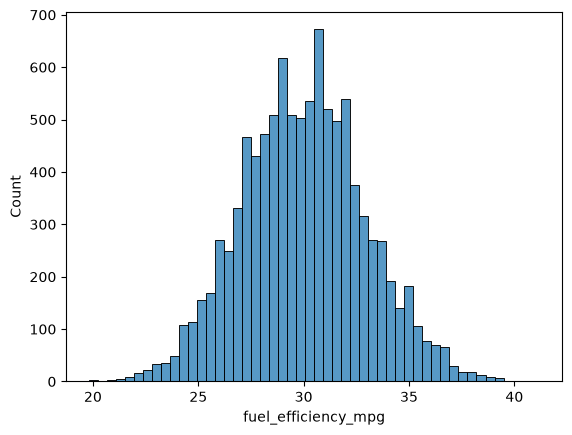

In [3]:
# Checking long tail in fuel efficiency
sns.histplot(data['fuel_efficiency_mpg'], bins=50)

In [4]:
data = data.drop(columns=[
    'origin',
    'fuel_type',
    'num_doors',
    'num_cylinders',
    'acceleration',
    'drivetrain'
])

In [5]:
# Checking for missing values
data.isnull().sum()

model_year               0
engine_displacement      0
horsepower             877
vehicle_weight           0
fuel_efficiency_mpg      0
dtype: int64

In [6]:
data.dtypes

model_year               int64
engine_displacement      int64
horsepower             float64
vehicle_weight           int64
fuel_efficiency_mpg    float64
dtype: object

In [7]:
# Median for horsepower variable
data['horsepower'].median()

np.float64(254.0)

In [8]:
# preparing data 
def split_data(df):
    df = df.copy()
    
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.seed(42)
    np.random.shuffle(idx)

    data_train = df.iloc[idx[:n_train]]
    data_val = df.iloc[idx[n_train:n_train+n_val]]
    data_test = df.iloc[idx[n_train+n_val:]]
    
    data_train = data_train.reset_index(drop=True) 
    data_val = data_val.reset_index(drop=True) 
    data_test = data_test.reset_index(drop=True) 

    return data_train, data_val, data_test

In [9]:
data_train, data_val, data_test = split_data(data)
data_train, data_val, data_test

(      model_year  engine_displacement  horsepower  vehicle_weight  \
 0           2015                 1900       239.0            3790   
 1           1992                 2000       224.0            4380   
 2           2022                 2330       286.0            4090   
 3           1997                 2300         NaN            4150   
 4           2001                 2340       269.0            4400   
 ...          ...                  ...         ...             ...   
 5995        2018                 2280       242.0            4590   
 5996        1984                 2300         NaN            4240   
 5997        1989                 2240       255.0            4190   
 5998        2020                 2430       254.0            4280   
 5999        1996                 2390       266.0            4220   
 
       fuel_efficiency_mpg  
 0                    32.5  
 1                    29.1  
 2                    34.1  
 3                    30.6  
 4           

In [10]:
def y_train(df_train, df_val, df_test, colname):
    df_train = df_train.copy()
    df_val = df_val.copy()
    df_test = df_test.copy()
    
    y_train = df_train[colname].values
    y_val = df_val[colname].values
    y_test = df_test[colname].values
        
    return y_train, y_val, y_test

# Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

In [11]:
# prepares data for linear regression model
def prepare_X(df):
    df = df.copy()
    features = ['engine_displacement',
                'horsepower',
                'vehicle_weight',
                'model_year']
    data_num = df[features]

    X = data_num.values
    return X
# Create a vector-vector multiplication linear regression
def dot(xi, w):
    n = len(xi)
    res = 0.0
    for j in range(n):
        res = res + xi[j] * w[j]
    return res
 # train a linear regression model
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    XTX.dot(XTX_inv)

    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]
    
# train a regularized linear regression model
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    XTX.dot(XTX_inv)

    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]
# calculate rmse for the model
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [13]:
# filling with 0 
df_train_filled_0 = data_train.copy()
df_train_filled_0['horsepower'] = df_train_filled_0['horsepower'].fillna(0)

df_val_filled_0 = data_val.copy()
df_val_filled_0['horsepower'] = df_val_filled_0['horsepower'].fillna(0)

y_train_filled_0 = df_train_filled_0['fuel_efficiency_mpg'].values 
y_val_filled_0 = df_val_filled_0['fuel_efficiency_mpg'].values 

# training model with no reg and filled with 0
X_train_0 = prepare_X(df_train_filled_0)
w0, w = train_linear_regression(X_train_0, y_train_filled_0)
X_val_0 = prepare_X(df_val_filled_0)
y_pred_0 = w0 + X_val_0.dot(w)

score_0 = rmse(y_val_filled_0, y_pred_0)
score_0

np.float64(2.205293194751098)

In [14]:
# filling with mean
mean_df = data_train['horsepower'].mean()

df_train_filled_mean = data_train.copy()
df_train_filled_mean['horsepower'] = df_train_filled_mean['horsepower'].fillna(mean_df)

df_val_filled_mean = data_val.copy()
df_val_filled_mean['horsepower'] = df_val_filled_mean['horsepower'].fillna(mean_df)

y_train_filled_mean = df_train_filled_mean['fuel_efficiency_mpg'].values 
y_val_filled_mean = df_val_filled_mean['fuel_efficiency_mpg'].values 

# training model with no reg and filled with mean
X_train_mean = prepare_X(df_train_filled_mean)
w0, w = train_linear_regression(X_train_mean, y_train_filled_mean)
X_val_mean = prepare_X(df_val_filled_mean)
y_pred_mean = w0 + X_val_mean.dot(w)

score_mean = rmse(y_val_filled_mean, y_pred_mean)
score_mean

np.float64(2.201817484568115)

In [15]:
# training a regularized model 
data_train, data_val, data_test = data_train.fillna(0), data_val.fillna(0), data_test.fillna(0)
y_train, y_val, y_test = data_train['fuel_efficiency_mpg'].values, data_val['fuel_efficiency_mpg'].values, data_test['fuel_efficiency_mpg'].values

#training model
r = [0, 0.01, 0.1, 1, 5, 10, 100]
for v in r:
    X_train = prepare_X(data_train)
    w0, w = train_linear_regression_reg(X_train, y_train, v)
    X_val = prepare_X(data_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    print(v, score)


    

0 2.205293194751098
0.01 2.205827616672006
0.1 2.2241432777850636
1 2.349228888392786
5 2.409380166599679
10 2.4194698654732387
100 2.4292021380162367


In [16]:
# model regularized
X_train = prepare_X(data_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0)
X_val = prepare_X(data_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(2.205293194751098)

# Question 5
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

In [17]:
def split_data_by_seed(df, s):
    df = df.copy()
    
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.seed(s)
    np.random.shuffle(idx)

    data_train = df.iloc[idx[:n_train]]
    data_val = df.iloc[idx[n_train:n_train+n_val]]
    data_test = df.iloc[idx[n_train+n_val:]]
    
    data_train = data_train.reset_index(drop=True) 
    data_val = data_val.reset_index(drop=True) 
    data_test = data_test.reset_index(drop=True) 

    return data_train, data_val, data_test

In [20]:
seed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores = []
for v in seed:
    data_train, data_val, data_test = split_data_by_seed(data, v)
    # training a regularized model 
    data_train, data_val, data_test = data_train.fillna(0), data_val.fillna(0), data_test.fillna(0)
    y_train, y_val, y_test = data_train['fuel_efficiency_mpg'].values, data_val['fuel_efficiency_mpg'].values, data_test['fuel_efficiency_mpg'].values
    
    #training model

    X_train = prepare_X(data_train)
    w0, w = train_linear_regression(X_train, y_train)
    X_val = prepare_X(data_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    scores.append(score)
    print(v, score)
    
np.std(scores).round(3)

0 2.2392041430461465
1 2.2021128210838907
2 2.163419778753095
3 2.2043588768539144
4 2.2018800943312926
5 2.2457851509084974
6 2.269721207952404
7 2.190794599933433
8 2.2166112016864443
9 2.207036592817851


np.float64(0.029)

In [31]:
#splitting data with seed 9
data_train, data_val, data_test = split_data_by_seed(data, 9)

# training a regularized model 
data_train, data_val, data_test = data_train.fillna(0), data_val.fillna(0), data_test.fillna(0)
y_train, y_val, y_test = data_train['fuel_efficiency_mpg'].values, data_val['fuel_efficiency_mpg'].values, data_test['fuel_efficiency_mpg'].values

# preparing data
X_train = prepare_X(data_train)
X_val = prepare_X(data_val)
                    
# full data train and val
X_full_train = np.concatenate([X_train, X_val])
y_full_train = np.concatenate([y_train, y_val])

#training model
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)


In [32]:
# testing the model
X_test = prepare_X(data_test)
y_pred = w0 + X_test.dot(w)

rmse(y_test, y_pred)

np.float64(2.2358277471917636)